In [18]:
import requests
from datetime import datetime
import time
import pandas as pd
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
sr = pd.read_csv('https://github.com/jdfoote/Intro-to-Programming-and-Data-Science/blob/fall2021/resources/data/sr_post_data.csv?raw=true')
sr.selftext = sr.selftext.fillna('')
sr['all_text'] = sr['title'] + ' ' + sr['selftext']

In [36]:
# Change the date to a datetime, and put it in the index
sr.index = pd.to_datetime(sr.date)

### EXERCISE 1

Modify the code above to plot how often "Coronavirus" is used in each of the three subreddits over time

In [45]:
sr.loc[:,['selftext', 'all_text']].sort_values('selftext')

,selftext,all_text
date,,
2021-09-25 03:59:39,,"FALSE: US records 12,366 deaths due to COVID-1..."
2021-09-14 04:12:25,,Congress exempt from Biden’s COVID-19 vaccine ...
2021-09-14 04:02:45,,CNBC poll shows very little will persuade unva...
2021-09-14 03:38:04,,House Democrats’ Plan to Tax the Rich Leaves V...
2021-09-14 03:30:35,,Mississippi abortion clinic asks Supreme Court...
...,...,...
2021-09-20 17:37:13,Welcome to the 'What happened in your state la...,"The ""What happened in your state last week?"" M..."
2021-09-13 16:08:17,Welcome to the 'What happened in your state la...,"The ""What happened in your state last week?"" M..."
2021-09-23 01:31:34,[deleted],ensuring all kids are safe [deleted]


/home/jeremy/miniforge3/envs/teaching/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


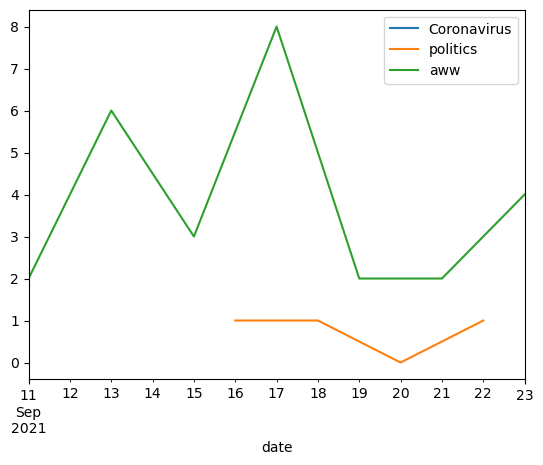

In [72]:
covid_only_df = sr.loc[sr.all_text.str.contains('cute')]
#print(covid_only_df)
for subreddit in covid_only_df.subreddit.unique():
    resampled_df = covid_only_df.loc[covid_only_df.subreddit == subreddit].resample('2D').size()
    #print(subreddit)
    #resampled_df = covid_only_df.resample('2D').size()
    resampled_df.plot(label=subreddit)
plt.legend();
plt.show();

### EXERCISE 2

One of the trickiest parts of analysis is getting the data in the form that you want it in order to analyze/visualize it. 

I think a good visualization for this would be a barplot showing how often male and female word types appear for each subreddit. I'll give you the final call to produce the plot:

`sns.barplot(x='subreddit', y='proportion', hue = 'word_gender', data = agg_df_long)`

Now, see if you can get the data in shape so that this code actually works! :)

*Hint: You'll want to use [wide to long](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.wide_to_long.html)*

In [73]:
# First we change NAs and removed/deleted to empty strings
sr.loc[(pd.isna(sr.selftext)) | (sr.selftext.isin(['[removed]', '[deleted]'])), 'selftext'] = ''
sr['all_text'] = sr.title + ' ' + sr.selftext

male_words = ['he', 'his']
female_words = ['she', 'hers']

# This puts all of the text of each subreddit into lists
def string_to_list(x):
    return ' '.join(x).split()
grouped_text = sr.groupby('subreddit').all_text.apply(string_to_list)

# Then, we count how often each type of words appears in each subreddit
agg = grouped_text.transform({'proportionMale': lambda x: sum([x.count(y) for y in male_words])/len(x),
                        'proportionFemale': lambda x: sum([x.count(y) for y in female_words])/len(x)}
                        )

In [80]:
agg.reset_index()

,subreddit,proportionMale,proportionFemale
0,Coronavirus,0.001874,0.000234
1,aww,0.011129,0.003251
2,politics,0.003950,0.000525


In [77]:
agg_df_long = pd.wide_to_long(agg.reset_index(), stubnames='proportion',
                i='subreddit', j='gender', suffix='.*') 

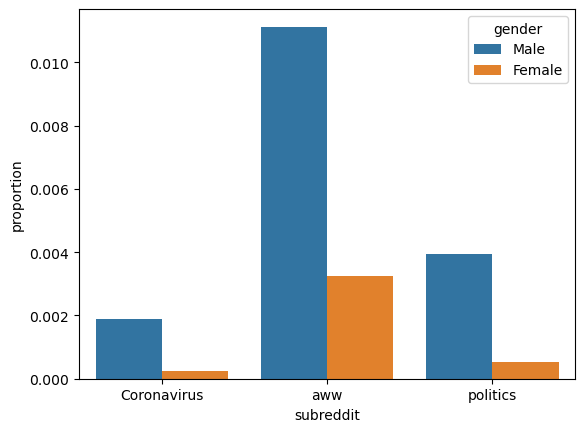

In [78]:
sns.barplot(x='subreddit', y='proportion', hue = 'gender', data = agg_df_long);

### EXERCISE 3

Make your own analysis, with a different set of terms

Goal: Compare how often risk-based terms appear across subreddits

### EXERCISE 4

Where topic modeling really shines is in analyzing longer texts - for example, the subreddit [changemyview](https://www.reddit.com/r/changemyview/) has fairly long posts where people explain a controversial view that they hold.

Try to figure out how to get a few hundred posts from changemyview, and run a topic model on them, where the selftext of each post is a document.